In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeat
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import netCDF4
from netCDF4 import Dataset
import numpy as np
import glob

import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import matplotlib.ticker as mticker
import matplotlib.colors as colors

from scipy import stats
import pandas as pd
import random
    
from datetime import date
from datetime import datetime, timedelta
import matplotlib.dates as mdates

from warnings import filterwarnings
filterwarnings(action='ignore')

import xarray
import metpy
from mpl_toolkits.basemap import Basemap

import wrf

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

from calc_stats import calc_stats


In [2]:
# load in data files

datadir = '/ships22/raqms/jacdan/AEROMMA_ANALYSES/6.AGES.CHICAGO.PAPER/'
curtain_files = sorted(glob.glob(datadir+'Searey*curtain_mission*.nc'))
track_files = sorted(glob.glob(datadir+'Searey*track_mission*.nc'))

#curtain_files = [curtain_files[:]]
#track_files = [track_files[:]]

print(curtain_files)
print(track_files)


['/ships22/raqms/jacdan/AEROMMA_ANALYSES/6.AGES.CHICAGO.PAPER/Searey_20230802_R0_L1_curtain_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc', '/ships22/raqms/jacdan/AEROMMA_ANALYSES/6.AGES.CHICAGO.PAPER/Searey_20230802_R0_L2_curtain_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc', '/ships22/raqms/jacdan/AEROMMA_ANALYSES/6.AGES.CHICAGO.PAPER/Searey_20230802_R0_L3_curtain_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc']
['/ships22/raqms/jacdan/AEROMMA_ANALYSES/6.AGES.CHICAGO.PAPER/Searey_20230802_R0_L1_track_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc', '/ships22/raqms/jacdan/AEROMMA_ANALYSES/6.AGES.CHICAGO.PAPER/Searey_20230802_R0_L2_track_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc', '/ships22/raqms/jacdan/AEROMMA_ANALYSES/6.AGES.CHICAGO.PAPER/Searey_20230802_R0_L3_track_mission_UW-Madison_WRFCHEM4km_AEROMMA_Retro_CFxR.nc']


In [3]:
obs_no2_all = []
mod_no2_all = []

obs_no2_l1 = []
mod_no2_l1 = []

obs_no2_l2 = []
mod_no2_l2 = []

obs_no2_l3 = []
mod_no2_l3 = []

for i in range(len(curtain_files)):
    dat_curtain = Dataset(curtain_files[i],'r')
    dat_track = Dataset(track_files[i],'r')

    obs_no2_track = dat_track.variables['no2_in_situ'][5*60:] # ppbv
    #obs_no2_track = np.where(obs_no2_track==0,np.nan,obs_no2_track)
    mod_no2_track = dat_track.variables['no2'][5*60:] # ppbv
    #mod_no2_track = np.where(mod_no2_track==0,np.nan,mod_no2_track)

    obs_utcsec_curtain = dat_curtain.variables['utcsec'][5*60:]/3600
    obs_no2_curtain = dat_curtain.variables['no2_in_situ'][5*60:]
    obs_alt_curtain = dat_curtain.variables['zco'][5*60:]
    
    mod_no2_curtain = (dat_curtain.variables['chem_curtain'][1,5*60:,:]).T
    mod_alt_curtain = (dat_curtain.variables['zcurt'][5*60:,:]).T
    
    mod_time_curtain = np.zeros(mod_no2_curtain.shape)
    mod_time_curtain[:,:] = np.nan
    
    for j in range(len(obs_utcsec_curtain)):
        mod_time_curtain[:,j] = obs_utcsec_curtain[j]

    for j in range(len(obs_no2_track)):
        obs_no2_all.append(obs_no2_track[j])

    for j in range(len(mod_no2_track)):
        mod_no2_all.append(mod_no2_track[j])

    if i == 0:

        for j in range(len(obs_no2_track)):
            obs_no2_l1.append(obs_no2_track[j])
    
        for j in range(len(mod_no2_track)):
            mod_no2_l1.append(mod_no2_track[j])

        obs_utcsec_curtain_l1 = obs_utcsec_curtain.copy()
        obs_alt_curtain_l1 = obs_alt_curtain.copy()
        obs_no2_curtain_l1 = obs_no2_curtain.copy()

        mod_time_curtain_l1 = mod_time_curtain.copy()
        mod_alt_curtain_l1 = mod_alt_curtain.copy()
        mod_no2_curtain_l1 = mod_no2_curtain.copy()
        
    if i == 1:

        for j in range(len(obs_no2_track)):
            obs_no2_l2.append(obs_no2_track[j])
    
        for j in range(len(mod_no2_track)):
            mod_no2_l2.append(mod_no2_track[j])

        obs_utcsec_curtain_l2 = obs_utcsec_curtain.copy()
        obs_alt_curtain_l2 = obs_alt_curtain.copy()
        obs_no2_curtain_l2 = obs_no2_curtain.copy()

        mod_time_curtain_l2 = mod_time_curtain.copy()
        mod_alt_curtain_l2 = mod_alt_curtain.copy()
        mod_no2_curtain_l2 = mod_no2_curtain.copy()

    if i == 2:

        for j in range(len(obs_no2_track)):
            obs_no2_l3.append(obs_no2_track[j])
    
        for j in range(len(mod_no2_track)):
            mod_no2_l3.append(mod_no2_track[j])
            
        obs_utcsec_curtain_l3 = obs_utcsec_curtain.copy()
        obs_alt_curtain_l3 = obs_alt_curtain.copy()
        obs_no2_curtain_l3 = obs_no2_curtain.copy()

        mod_time_curtain_l3 = mod_time_curtain.copy()
        mod_alt_curtain_l3 = mod_alt_curtain.copy()
        mod_no2_curtain_l3 = mod_no2_curtain.copy()

    print('Leg 0'+str(i+1))
    print(np.nanmin(obs_no2_track),np.nanmax(obs_no2_track))
    print(np.nanmin(mod_no2_track),np.nanmax(mod_no2_track))
    print(len(obs_no2_track))
    print('')


Leg 01
0.0 10.46
1.5004995 10.575962
5465

Leg 02
0.0 2.45
0.0 2.4632728
5572

Leg 03
0.0 3.71
0.0 4.86899
9402



In [4]:
# Code to find nans in obs (assigned to 0 values for plotting) --> not doing based on Mike Newchurch's email
#nan_val_l1_x = np.array(obs_utcsec_curtain_l1)[np.where(np.isnan(np.array(obs_no2_l1)))[0]]
#nan_val_l2_x = np.array(obs_utcsec_curtain_l2)[np.where(np.isnan(np.array(obs_no2_l2)))[0]]
#nan_val_l3_x = np.array(obs_utcsec_curtain_l3)[np.where(np.isnan(np.array(obs_no2_l3)))[0]]

#nan_val_l1_y = np.array(obs_alt_curtain_l1)[np.where(np.isnan(np.array(obs_no2_l1)))[0]]
#nan_val_l2_y = np.array(obs_alt_curtain_l2)[np.where(np.isnan(np.array(obs_no2_l2)))[0]]
#nan_val_l3_y = np.array(obs_alt_curtain_l3)[np.where(np.isnan(np.array(obs_no2_l3)))[0]]


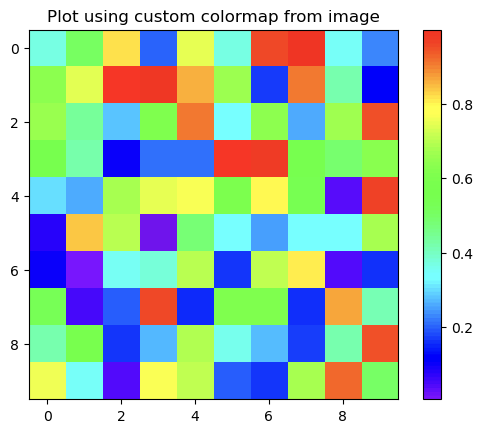

In [5]:
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def create_cmap_from_colorbar_image(image_path):
    """
    Creates a Matplotlib colormap from a color bar image.

    Args:
        image_path (str): The file path to the color bar image.

    Returns:
        matplotlib.colors.LinearSegmentedColormap: The custom colormap.
    """
    # 1. Load the image
    img = mpimg.imread(image_path)
    
    # 2. Extract the relevant pixel data
    # Assuming a vertical color bar, we take the first column of pixels (index 0)
    # and all rows. The last dimension [:] gets the R, G, B, A values.
    # Adjust the column index (e.g., to a middle column if the first has a border) 
    # if necessary.
    colors_from_img = img[:, 0, :]
    
    # The number of entries in the colormap should match the number of pixels in 
    # the color bar image (the height of the image).
    N = img.shape[0]
    
    # 3. Create the LinearSegmentedColormap
    # The 'colors_from_img' is a list of colors which is used to define the map.
    custom_cmap = LinearSegmentedColormap.from_list('custom_colorbar', colors_from_img, N=N)
    
    return custom_cmap

# --- Usage Example ---
# Replace 'path/to/your/colorbar_image.png' with the actual path to your image file
image_path = '/home/jacdan/AEROMMA/6.AGES.CHICAGO/Laura.Rainbow.Colorbar.png' 

try:
    my_cmap = create_cmap_from_colorbar_image(image_path)
    
    # 4. Use the new colormap
    # Example: Display some random data using the custom colormap
    data = np.random.rand(10, 10)
    plt.imshow(data, cmap=my_cmap)
    plt.colorbar()
    plt.title("Plot using custom colormap from image")
    plt.show()

except FileNotFoundError:
    print(f"Error: Image file not found at {image_path}")
    print("Please update the 'image_path' variable to your image's location.")


42.0
742.0
877.0


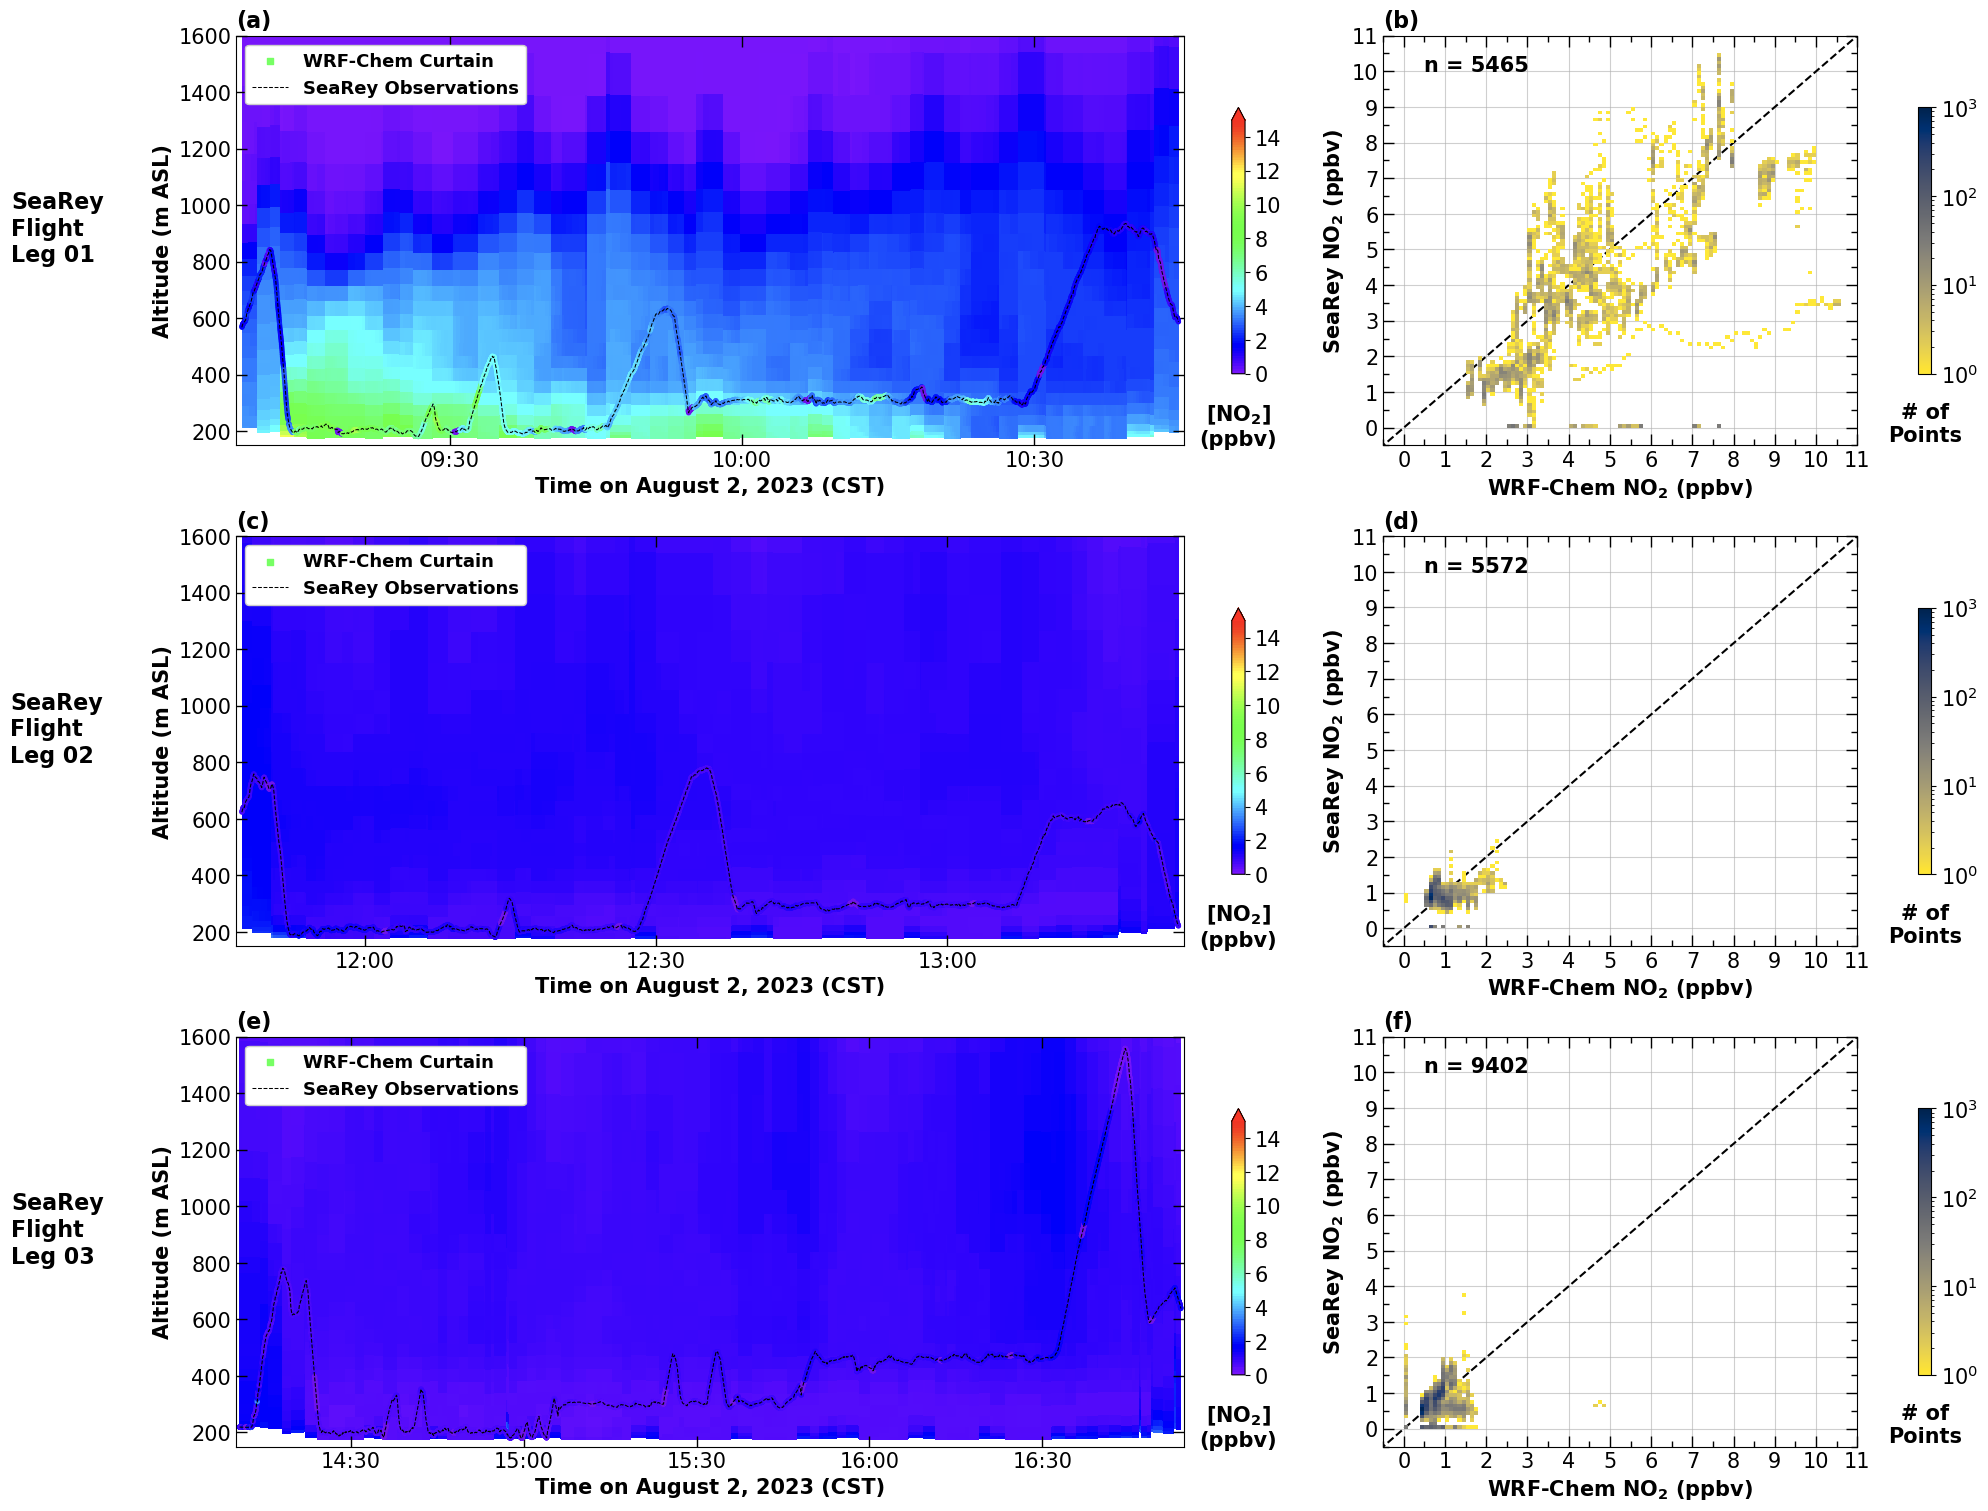

In [6]:
# plot non-standardized colorbars

fig = plt.figure(figsize=(20, 15),constrained_layout=True)
gs = fig.add_gridspec(3,3)

i = 0
row_idx = [0,0,1,1,2,2]

flight_leg = ['01','01','02','02','03']
flight_leg_x = [14.75,[],17.39,[],19.518]

# scatter data and plotting specifics
scatter_x_mod = [[],mod_no2_l1,[],mod_no2_l2,[],mod_no2_l3]
scatter_y_obs = [[],obs_no2_l1,[],obs_no2_l2,[],obs_no2_l3]
scatter_bins = [[],110,[],110,[],110]
scatter_range_max = [[],11,[],11,[],11]
norm_vmax = [[],1000,[],1000,[],1000]
scatter_text_x = [[],0.5,[],0.5,[],0.5]
scatter_text_y = [[],10,[],10,[],10]

# curtain data and plotting specifics
curtain_x_mod = [mod_time_curtain_l1,[],mod_time_curtain_l2,[],mod_time_curtain_l3,[]]
curtain_y_mod = [mod_alt_curtain_l1,[],mod_alt_curtain_l2,[],mod_alt_curtain_l3,[]]
curtain_c_mod = [mod_no2_curtain_l1,[],mod_no2_curtain_l2,[],mod_no2_curtain_l3,[]]

curtain_x_obs = [obs_utcsec_curtain_l1,[],obs_utcsec_curtain_l2,[],obs_utcsec_curtain_l3,[]]
curtain_y_obs = [obs_alt_curtain_l1,[],obs_alt_curtain_l2,[],obs_alt_curtain_l3,[]]
curtain_c_obs = [obs_no2_curtain_l1,[],obs_no2_curtain_l2,[],obs_no2_curtain_l3,[]]
curtain_vmax = [15,[],15,[],15,[]]
curtain_ymax = [1600,[],1600,[],1600,[]]

curtain_xticks = [[15.5,16.0,16.5],[],[18.0,18.5,19.0],[],[20.5,21.0,21.5,22.0,22.5],[]]
#curtain_xtick_labels = [['15:30','16:00','16:30'],[],['18:00','18:30','19:00'],[],['20:30','21:00','21:30','22:00','22:30'],[]]
curtain_xtick_labels = [['09:30','10:00','10:30'],[],['12:00','12:30','13:00'],[],['14:30','15:00','15:30','16:00','16:30'],[]]

#plot_titles = ['(a)','(d)','(b)','(e)','(c)','(f)'] # down columns
plot_titles = ['(a)','(b)','(c)','(d)','(e)','(f)'] # across rows

for i in range(6):

    # plot curtain plots
    if i in [0,2,4]:
        
        ax = fig.add_subplot(gs[row_idx[i],0:2])

        # wrf-chem curtain
        b = ax.pcolormesh(curtain_x_mod[i],curtain_y_mod[i],curtain_c_mod[i],cmap=my_cmap,vmin=0,vmax=curtain_vmax[i],zorder=0)
        # plotting example point from wrf-chem curtain for legend label
        ax.scatter(curtain_x_mod[i][20,50],curtain_y_mod[i][20,50],c=curtain_vmax[i]/2,s=25,marker='s',cmap=my_cmap,vmin=0,vmax=curtain_vmax[i],zorder=-5,label='WRF-Chem Curtain')
        # plotting searey obs as scatter points
        ax.scatter(curtain_x_obs[i],curtain_y_obs[i],c=curtain_c_obs[i],s=8,cmap=my_cmap,vmin=0,vmax=curtain_vmax[i],zorder=9)
        # plotting dashed line along searey obs for easier identification and for legend label
        ax.plot(curtain_x_obs[i],curtain_y_obs[i],c='k',linestyle='dashed',linewidth=0.75,label='SeaRey Observations',zorder=10)
        ax.set_ylim([150,curtain_ymax[i]])
        ax.set_xlim([np.min(curtain_x_obs[i])-0.01,np.max(curtain_x_obs[i])+0.01])

        # identify nan values as where the plot looks like 0 values
        #if i == 0:
        #    ax.scatter(nan_val_l1_x ,nan_val_l1_y,c='white',s=30,marker='s',alpha=1.0,zorder=11)
        #if i == 2:
        #    ax.scatter(nan_val_l2_x ,nan_val_l2_y,c='white',s=30,marker='s',alpha=1.0,zorder=11)
        #if i == 4:
        #    ax.scatter(nan_val_l3_x ,nan_val_l3_y,c='white',s=30,marker='s',alpha=1.0,zorder=11)

        c = plt.colorbar(b,shrink=0.65,pad=0.05,extend='max')
        tick_positions = [0,2,4,6,8,10,12,14]
        tick_labels = ['0','2','4','6','8','10','12','14']
        c.set_ticks(tick_positions)
        c.set_ticklabels(tick_labels)
        c.ax.set_xlabel('\n'+r'[NO$_{\rm \bf{2}}$]'+'\n(ppbv)',fontsize=15,fontweight='bold')
        c.ax.tick_params(labelsize=15)

        #ax.xaxis.set_major_locator(MultipleLocator(2))
        #ax.xaxis.set_minor_locator(AutoMinorLocator())
        #ax.yaxis.set_major_locator(MultipleLocator())
        #ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.set_xticks(curtain_xticks[i],curtain_xtick_labels[i])
        ax.tick_params(which='both', width=1,top=True,right=True,bottom=True,direction='in')
        ax.tick_params(which='major', length=8,top=True,right=True,bottom=True,direction='in',labelsize=15)
        ax.tick_params(which='minor', length=4, color='k',top=True,right=True,direction='in')

        #if i == 4:
        ax.set_xlabel('Time on August 2, 2023 (CST)',fontsize=15,fontweight='bold')
        ax.set_ylabel('Altitude (m ASL)',fontsize=15,fontweight='bold')
        ax.set_title(plot_titles[i],loc='left',fontweight='bold',fontsize=16)
        ax.legend(loc='upper left',framealpha=1.0,prop={'weight':'bold','size':13})

        ax.text(flight_leg_x[i],curtain_ymax[i]/2,'SeaRey\nFlight\nLeg '+flight_leg[i],fontweight='bold',fontsize=16)

    # plot scatter plots
    if i in [1,3,5]:
        
        ax = fig.add_subplot(gs[row_idx[i],2])
        
        b = ax.hist2d(scatter_x_mod[i],scatter_y_obs[i],bins=scatter_bins[i],
                      range=[[0,scatter_range_max[i]],[0,scatter_range_max[i]]],
                      cmin=1,cmap='cividis_r',norm=colors.LogNorm(vmin=1,vmax=norm_vmax[i]),zorder=10)

        print(np.nanmax(b[0]))
        c = plt.colorbar(b[3],shrink=0.65,pad=0.1)
        c.ax.set_xlabel('\n# of\nPoints',fontsize=15,fontweight='bold')
        c.ax.tick_params(labelsize=15)

        ax.text(scatter_text_x[i],scatter_text_y[i],'n = '+str(len(scatter_x_mod[i])),fontsize=15,fontweight='bold')
        
        ax.plot([-1,scatter_range_max[i]+1],[-1,scatter_range_max[i]+1],c='k',linestyle='dashed',zorder=9)
        ax.set_xlim([-0.5,scatter_range_max[i]])
        ax.set_ylim([-0.5,scatter_range_max[i]])

        ax.set_xlabel(r'WRF-Chem NO$_{\rm \bf{2}}$ (ppbv)',fontsize=15,fontweight='bold')
        ax.set_ylabel('\n'+r'SeaRey NO$_{\rm \bf{2}}$ (ppbv)',fontsize=15,fontweight='bold')
        ax.set_title(plot_titles[i],loc='left',fontweight='bold',fontsize=16)

        ax.xaxis.set_major_locator(MultipleLocator())
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_major_locator(MultipleLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(which='both', width=1,top=True,right=True,bottom=True,direction='in')
        ax.tick_params(which='major', length=8,top=True,right=True,bottom=True,direction='in',labelsize=15)
        ax.tick_params(which='minor', length=4, color='k',top=True,right=True,direction='in')

        ax.grid(alpha=0.6)

plt.savefig('AGES.Chicago.WRFChem.SeaRey.NO2.Comparison.Standardized.c20260305.png',dpi=300)
plt.show()


# Code for previous figure versions

# NOT USING THIS VERSION OF THE FIGURE CODE

### plot non-standardized colorbars
fig = plt.figure(figsize=(20, 15),constrained_layout=True)
gs = fig.add_gridspec(3,3)

i = 0
row_idx = [0,0,1,1,2,2]

flight_leg = ['01','01','02','02','03']
flight_leg_x = [14.75,[],17.39,[],19.518]

### scatter data and plotting specifics
scatter_x_mod = [[],mod_no2_l1,[],mod_no2_l2,[],mod_no2_l3]
scatter_y_obs = [[],obs_no2_l1,[],obs_no2_l2,[],obs_no2_l3]
scatter_bins = [[],110,[],30,[],50]
scatter_range_max = [[],11,[],3,[],5]
norm_vmax = [[],50,[],1000,[],1000]
scatter_text_x = [[],0.5,[],0.15,[],0.25]
scatter_text_y = [[],10,[],2.75,[],4.5]

### curtain data and plotting specifics
curtain_x_mod = [mod_time_curtain_l1,[],mod_time_curtain_l2,[],mod_time_curtain_l3,[]]
curtain_y_mod = [mod_alt_curtain_l1,[],mod_alt_curtain_l2,[],mod_alt_curtain_l3,[]]
curtain_c_mod = [mod_no2_curtain_l1,[],mod_no2_curtain_l2,[],mod_no2_curtain_l3,[]]

curtain_x_obs = [obs_utcsec_curtain_l1,[],obs_utcsec_curtain_l2,[],obs_utcsec_curtain_l3,[]]
curtain_y_obs = [obs_alt_curtain_l1,[],obs_alt_curtain_l2,[],obs_alt_curtain_l3,[]]
curtain_c_obs = [obs_no2_curtain_l1,[],obs_no2_curtain_l2,[],obs_no2_curtain_l3,[]]
curtain_vmax = [11,[],3,[],5,[]]
curtain_ymax = [1000,[],900,[],1600,[]]

curtain_xticks = [[15.5,16.0,16.5],[],[18.0,18.5,19.0],[],[20.5,21.0,21.5,22.0,22.5],[]]
curtain_xtick_labels = [['15:30','16:00','16:30'],[],['18:00','18:30','19:00'],[],['20:30','21:00','21:30','22:00','22:30'],[]]

for i in range(6):
    if i in [0,2,4]:
        
        ax = fig.add_subplot(gs[row_idx[i],0:2])
        
        b = ax.pcolormesh(curtain_x_mod[i],curtain_y_mod[i],curtain_c_mod[i],cmap='inferno_r',vmin=0,vmax=curtain_vmax[i])
        ax.scatter(curtain_x_mod[i][20,50],curtain_y_mod[i][20,50],c=curtain_vmax[i]/2,s=25,marker='s',cmap='inferno_r',vmin=0,vmax=curtain_vmax[i],zorder=-1,label='WRF-Chem Curtain')
        ax.scatter(curtain_x_obs[i],curtain_y_obs[i],c=curtain_c_obs[i],s=25,cmap='inferno_r',vmin=0,vmax=curtain_vmax[i])
        ax.plot(curtain_x_obs[i],curtain_y_obs[i],c='k',linestyle='dashed',linewidth=0.75,label='SeaRey Observations')
        ax.set_ylim([150,curtain_ymax[i]])
        ax.set_xlim([np.min(curtain_x_obs[i])-0.01,np.max(curtain_x_obs[i])+0.01])

        c = plt.colorbar(b,shrink=0.65,pad=0.05)
        c.ax.set_xlabel('\n'+r'[NO$_{\rm \bf{2}}$]'+'\n(ppbv)',fontsize=15,fontweight='bold')
        c.ax.tick_params(labelsize=15)

        #ax.xaxis.set_major_locator(MultipleLocator(2))
        #ax.xaxis.set_minor_locator(AutoMinorLocator())
        #ax.yaxis.set_major_locator(MultipleLocator())
        #ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.set_xticks(curtain_xticks[i],curtain_xtick_labels[i])
        ax.tick_params(which='both', width=1,top=True,right=True,bottom=True,direction='in')
        ax.tick_params(which='major', length=8,top=True,right=True,bottom=True,direction='in',labelsize=15)
        ax.tick_params(which='minor', length=4, color='k',top=True,right=True,direction='in')

        #if i == 4:
        ax.set_xlabel('Time on 02 August 2023 (UTC)',fontsize=15,fontweight='bold')
        ax.set_ylabel('Altitude (m ASL)',fontsize=15,fontweight='bold')
        #ax.set_title(r'SeaRey Flight Leg '+flight_leg[i],loc='left',fontweight='bold',fontsize=16)
        ax.legend(loc='upper left',framealpha=1.0,prop={'weight':'bold','size':13})

        ax.text(flight_leg_x[i],curtain_ymax[i]/2,'SeaRey\nFlight\nLeg '+flight_leg[i],fontweight='bold',fontsize=16)

        
    if i in [1,3,5]:
        
        ax = fig.add_subplot(gs[row_idx[i],2])
        
        b = ax.hist2d(scatter_x_mod[i],scatter_y_obs[i],bins=scatter_bins[i],
                      range=[[0,scatter_range_max[i]],[0,scatter_range_max[i]]],
                      cmin=1,cmap='cividis_r',norm=colors.LogNorm(vmin=1,vmax=norm_vmax[i]),zorder=10)

        print(np.nanmax(b[0]))
        c = plt.colorbar(b[3],shrink=0.65,pad=0.1)
        c.ax.set_xlabel('\n# of\nPoints',fontsize=15,fontweight='bold')
        c.ax.tick_params(labelsize=15)

        ax.text(scatter_text_x[i],scatter_text_y[i],'n = '+str(len(scatter_x_mod[i])),fontsize=15,fontweight='bold')
        
        ax.plot([-1,scatter_range_max[i]+1],[-1,scatter_range_max[i]+1],c='k',linestyle='dashed',zorder=9)
        ax.set_xlim([0,scatter_range_max[i]])
        ax.set_ylim([0,scatter_range_max[i]])

        ax.set_xlabel(r'WRF-Chem NO$_{\rm \bf{2}}$ (ppbv)',fontsize=15,fontweight='bold')
        ax.set_ylabel('\n'+r'SeaRey NO$_{\rm \bf{2}}$ (ppbv)',fontsize=15,fontweight='bold')
        #ax.set_title('SeaRey Flight Leg 0'++'\n',fontsize=15,fontweight='bold',loc='center')

        ax.xaxis.set_major_locator(MultipleLocator())
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_major_locator(MultipleLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(which='both', width=1,top=True,right=True,bottom=True,direction='in')
        ax.tick_params(which='major', length=8,top=True,right=True,bottom=True,direction='in',labelsize=15)
        ax.tick_params(which='minor', length=4, color='k',top=True,right=True,direction='in')

        ax.grid(alpha=0.6)

#plt.savefig('Main.Text.Figure.V1.non.standardized.colorbars.png',dpi=300)
plt.show()


# NOT USING THIS VERSION OF THE FIGURE CODE
### plot non-standardized colorbars

fig = plt.figure(figsize=(20, 15),constrained_layout=True)
gs = fig.add_gridspec(3,3)

i = 0
row_idx = [0,0,1,1,2,2]

flight_leg = ['01','01','02','02','03']
flight_leg_x = [14.75,[],17.39,[],19.518]

### scatter data and plotting specifics
scatter_x_mod = [[],mod_no2_l1,[],mod_no2_l2,[],mod_no2_l3]
scatter_y_obs = [[],obs_no2_l1,[],obs_no2_l2,[],obs_no2_l3]
scatter_bins = [[],110,[],110,[],110]
scatter_range_max = [[],11,[],11,[],11]
norm_vmax = [[],1000,[],1000,[],1000]
scatter_text_x = [[],0.5,[],0.5,[],0.5]
scatter_text_y = [[],10,[],10,[],10]

### curtain data and plotting specifics
curtain_x_mod = [mod_time_curtain_l1,[],mod_time_curtain_l2,[],mod_time_curtain_l3,[]]
curtain_y_mod = [mod_alt_curtain_l1,[],mod_alt_curtain_l2,[],mod_alt_curtain_l3,[]]
curtain_c_mod = [mod_no2_curtain_l1,[],mod_no2_curtain_l2,[],mod_no2_curtain_l3,[]]

curtain_x_obs = [obs_utcsec_curtain_l1,[],obs_utcsec_curtain_l2,[],obs_utcsec_curtain_l3,[]]
curtain_y_obs = [obs_alt_curtain_l1,[],obs_alt_curtain_l2,[],obs_alt_curtain_l3,[]]
curtain_c_obs = [obs_no2_curtain_l1,[],obs_no2_curtain_l2,[],obs_no2_curtain_l3,[]]
curtain_vmax = [11,[],11,[],11,[]]
curtain_ymax = [1600,[],1600,[],1600,[]]

curtain_xticks = [[15.5,16.0,16.5],[],[18.0,18.5,19.0],[],[20.5,21.0,21.5,22.0,22.5],[]]
#curtain_xtick_labels = [['15:30','16:00','16:30'],[],['18:00','18:30','19:00'],[],['20:30','21:00','21:30','22:00','22:30'],[]]
curtain_xtick_labels = [['09:30','10:00','10:30'],[],['12:00','12:30','13:00'],[],['14:30','15:00','15:30','16:00','16:30'],[]]

plot_titles = ['(a)','(b)','(c)','(d)','(e)','(f)']

for i in range(6):

    # plot curtain plots
    if i in [0,2,4]:
        
        ax = fig.add_subplot(gs[row_idx[i],0:2])

        # wrf-chem curtain
        b = ax.pcolormesh(curtain_x_mod[i],curtain_y_mod[i],curtain_c_mod[i],cmap='inferno_r',vmin=0,vmax=curtain_vmax[i],zorder=0)
        # plotting example point from wrf-chem curtain for legend label
        ax.scatter(curtain_x_mod[i][20,50],curtain_y_mod[i][20,50],c=curtain_vmax[i]/2,s=25,marker='s',cmap='inferno_r',vmin=0,vmax=curtain_vmax[i],zorder=-5,label='WRF-Chem Curtain')
        # plotting searey obs as scatter points
        ax.scatter(curtain_x_obs[i],curtain_y_obs[i],c=curtain_c_obs[i],s=8,cmap='inferno_r',vmin=0,vmax=curtain_vmax[i],zorder=9)
        # plotting dashed line along searey obs for easier identification and for legend label
        ax.plot(curtain_x_obs[i],curtain_y_obs[i],c='k',linestyle='dashed',linewidth=0.75,label='SeaRey Observations',zorder=10)
        ax.set_ylim([150,curtain_ymax[i]])
        ax.set_xlim([np.min(curtain_x_obs[i])-0.01,np.max(curtain_x_obs[i])+0.01])

        # identify nan values as where the plot looks like 0 values
        #if i == 0:
        #    ax.scatter(nan_val_l1_x ,nan_val_l1_y,c='white',s=30,marker='s',alpha=1.0,zorder=11)
        #if i == 2:
        #    ax.scatter(nan_val_l2_x ,nan_val_l2_y,c='white',s=30,marker='s',alpha=1.0,zorder=11)
        #if i == 4:
        #    ax.scatter(nan_val_l3_x ,nan_val_l3_y,c='white',s=30,marker='s',alpha=1.0,zorder=11)

        c = plt.colorbar(b,shrink=0.65,pad=0.05)
        c.ax.set_xlabel('\n'+r'[NO$_{\rm \bf{2}}$]'+'\n(ppbv)',fontsize=15,fontweight='bold')
        c.ax.tick_params(labelsize=15)

        #ax.xaxis.set_major_locator(MultipleLocator(2))
        #ax.xaxis.set_minor_locator(AutoMinorLocator())
        #ax.yaxis.set_major_locator(MultipleLocator())
        #ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.set_xticks(curtain_xticks[i],curtain_xtick_labels[i])
        ax.tick_params(which='both', width=1,top=True,right=True,bottom=True,direction='in')
        ax.tick_params(which='major', length=8,top=True,right=True,bottom=True,direction='in',labelsize=15)
        ax.tick_params(which='minor', length=4, color='k',top=True,right=True,direction='in')

        #if i == 4:
        ax.set_xlabel('Time on 02 August 2023 (CST)',fontsize=15,fontweight='bold')
        ax.set_ylabel('Altitude (m ASL)',fontsize=15,fontweight='bold')
        ax.set_title(plot_titles[i],loc='left',fontweight='bold',fontsize=16)
        ax.legend(loc='upper left',framealpha=1.0,prop={'weight':'bold','size':13})

        ax.text(flight_leg_x[i],curtain_ymax[i]/2,'SeaRey\nFlight\nLeg '+flight_leg[i],fontweight='bold',fontsize=16)

    # plot scatter plots
    if i in [1,3,5]:
        
        ax = fig.add_subplot(gs[row_idx[i],2])
        
        b = ax.hist2d(scatter_x_mod[i],scatter_y_obs[i],bins=scatter_bins[i],
                      range=[[0,scatter_range_max[i]],[0,scatter_range_max[i]]],
                      cmin=1,cmap='cividis_r',norm=colors.LogNorm(vmin=1,vmax=norm_vmax[i]),zorder=10)

        print(np.nanmax(b[0]))
        c = plt.colorbar(b[3],shrink=0.65,pad=0.1)
        c.ax.set_xlabel('\n# of\nPoints',fontsize=15,fontweight='bold')
        c.ax.tick_params(labelsize=15)

        ax.text(scatter_text_x[i],scatter_text_y[i],'n = '+str(len(scatter_x_mod[i])),fontsize=15,fontweight='bold')
        
        ax.plot([-1,scatter_range_max[i]+1],[-1,scatter_range_max[i]+1],c='k',linestyle='dashed',zorder=9)
        ax.set_xlim([-0.25,scatter_range_max[i]])
        ax.set_ylim([-0.25,scatter_range_max[i]])

        ax.set_xlabel(r'WRF-Chem NO$_{\rm \bf{2}}$ (ppbv)',fontsize=15,fontweight='bold')
        ax.set_ylabel('\n'+r'SeaRey NO$_{\rm \bf{2}}$ (ppbv)',fontsize=15,fontweight='bold')
        ax.set_title(plot_titles[i],loc='left',fontweight='bold',fontsize=16)

        ax.xaxis.set_major_locator(MultipleLocator())
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_major_locator(MultipleLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(which='both', width=1,top=True,right=True,bottom=True,direction='in')
        ax.tick_params(which='major', length=8,top=True,right=True,bottom=True,direction='in',labelsize=15)
        ax.tick_params(which='minor', length=4, color='k',top=True,right=True,direction='in')

        ax.grid(alpha=0.6)

#plt.savefig('AGES.Chicago.Modeling.Main.Text.Figure.SeaRey.NO2.Comparison.standardized.V1.png',dpi=300)
plt.show()


# Checking smallest model NO2 values

moddir = '/ships22/raqms/jacdan/AEROMMA_STAQS_RETRO/ContinuousRuns/CHI/CANFIRES_NEW_V2_COMPLETE/FINAL_ALL_FILES_4KM/'
modfn = moddir+'wrfout_d01_2023-08-02*'
mod_files = sorted(glob.glob(modfn))

for i in range(len(mod_files)):
    mod_temp = Dataset(mod_files[i],'r')
    mod_temp_no2 = mod_temp.variables['no2'][:,:,:,:]*1000
    print(np.min(mod_temp_no2),np.max(mod_temp_no2))

# Checking where model and or searey values are 0
test_mod = np.array(mod_no2_all)
test_mod_0_idx = np.where(test_mod==0)[0]
test_obs = np.array(obs_no2_all)
#test_obs[test_mod_0_idx]

plt.scatter(np.arange(len(mod_no2_all))[test_mod_0_idx],np.ones(len(test_mod_0_idx))*(np.nanmax(obs_no2_all)+0.5),s=10,c='purple',marker='*')
plt.plot(np.arange(len(mod_no2_all)),mod_no2_all,c='r',zorder=2)
plt.plot(np.arange(len(obs_no2_all)),obs_no2_all,c='k',zorder=1)
plt.hlines(xmin=-10,xmax=len(mod_no2_all),y=0,color='blue',zorder=-1)
#plt.xlim([11000,15000])
#plt.ylim([-1,5])
plt.show()